In [ ]:
!pip install transformers torch scikit-learn imbalanced-learn nltk beautifulsoup4 seaborn matplotlib pandas numpy
!git clone https://github.com/kinit-sk/medical-misinformation-dataset

Cloning into 'medical-misinformation-dataset'...
remote: Enumerating objects: 48, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 48 (delta 9), reused 10 (delta 4), pack-reused 24 (from 1)
Receiving objects: 100% (48/48), 3.22 MiB | 3.28 MiB/s, done.
Resolving deltas: 100% (10/10), done.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os

# Text cleaning — NEW
from bs4 import BeautifulSoup
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# ML — mostly same as before
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# SMOTE for class imbalance — NEW
from imblearn.over_sampling import SMOTE

# PyTorch + HuggingFace for BioBERT — CHANGED (was using pipeline with SST-2 sentiment model)
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

In [ ]:
df = pd.read_csv("/content/medical-misinformation-dataset/sample_data/claims.csv")
df = df.rename(columns={"statement": "claim", "rating": "label"})
print("Shape:", df.shape)
print(df['label'].value_counts())

Shape: (1000, 9)
label
false           349
unknown         202
true             56
mostly-true      19
mixture          18
mostly-false     13
Name: count, dtype: int64


In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    """
    Cleans a single text string:
    1. Remove HTML tags (many descriptions have <p>, <a href> etc.)
    2. Lowercase everything
    3. Remove URLs
    4. Remove special characters and numbers
    5. Remove stopwords (common words like 'the', 'is' that don't help)
    6. Lemmatize (convert 'running' -> 'run', 'vaccines' -> 'vaccine')
    """
    if not isinstance(text, str):
        return ""

    # Step 1: Remove HTML tags
    text = BeautifulSoup(text, "html.parser").get_text()

    # Step 2: Lowercase
    text = text.lower()

    # Step 3: Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Step 4: Keep only letters and spaces
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Step 5 & 6: Tokenize, remove stopwords, lemmatize
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2]

    return " ".join(tokens)

# Apply cleaning to the 'claim' column
df['claim_clean'] = df['claim'].apply(clean_text)

print("\nOriginal claim:")
print(df['claim'].iloc[0])
print("\nCleaned claim:")
print(df['claim_clean'].iloc[0])


Original claim:
Dawn dish soap contains ammonia even though it's not listed as an ingredient, and when mixed with Clorox bleach products, the results could be lethal.

Cleaned claim:
dawn dish soap contains ammonia even though listed ingredient mixed clorox bleach product result could lethal


In [ ]:
df = df[['claim', 'claim_clean', 'label']].dropna(subset=['claim_clean', 'label'])
df['label'] = df['label'].astype(str).str.lower().str.strip()

# CHANGED: Comprehensive mapping — keeps ~636 rows instead of ~405
label_map = {
    'true':         1,
    'mostly-true':  1,   # Was ignored before — now included
    'false':        0,
    'mostly-false': 0,   # Was ignored before — now included
    'mixture':      0,   # Was ignored before — now included
    # 'unknown' is intentionally excluded — genuinely ambiguous
}

df['label'] = df['label'].map(label_map)
df = df.dropna(subset=['label'])  # Drops only 'unknown' rows now
df['label'] = df['label'].astype(int)

print("Label distribution after fix:")
print(df['label'].value_counts())
print(f"\nTotal usable rows: {len(df)}")


Label distribution after fix:
label
0    380
1     75
Name: count, dtype: int64

Total usable rows: 455


In [ ]:
X = df['claim_clean']
y = df['label']

# CHANGED: Use stratify=y to ensure both classes appear in train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # NEW — ensures balanced split
)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
print("Train label distribution:")
print(y_train.value_counts())

Train size: 364, Test size: 91
Train label distribution:
label
0    304
1     60
Name: count, dtype: int64


In [ ]:

# Step 1: Convert text to TF-IDF features
vectorizer = TfidfVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec  = vectorizer.transform(X_test)

# Step 2: Apply SMOTE on the training data only — NEW
# SMOTE creates synthetic 'true' examples so classes are balanced
# Note: SMOTE needs dense arrays, not sparse matrices
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_vec, y_train)

print("After SMOTE:")
print(pd.Series(y_train_balanced).value_counts())

# Step 3: Train Logistic Regression
# CHANGED: Added class_weight='balanced' as a safety net on top of SMOTE
model_lr = LogisticRegression(max_iter=200, class_weight='balanced', random_state=42)
model_lr.fit(X_train_balanced, y_train_balanced)

# Step 4: Evaluate
y_pred_lr = model_lr.predict(X_test_vec)

print("\n--- Logistic Regression Results ---")
print(classification_report(y_test, y_pred_lr, target_names=['False (0)', 'True (1)']))
print("Accuracy:", round(accuracy_score(y_test, y_pred_lr), 4))

After SMOTE:
label
0    304
1    304
Name: count, dtype: int64

--- Logistic Regression Results ---
              precision    recall  f1-score   support

   False (0)       0.86      0.91      0.88        76
    True (1)       0.36      0.27      0.31        15

    accuracy                           0.80        91
   macro avg       0.61      0.59      0.60        91
weighted avg       0.78      0.80      0.79        91

Accuracy: 0.8022


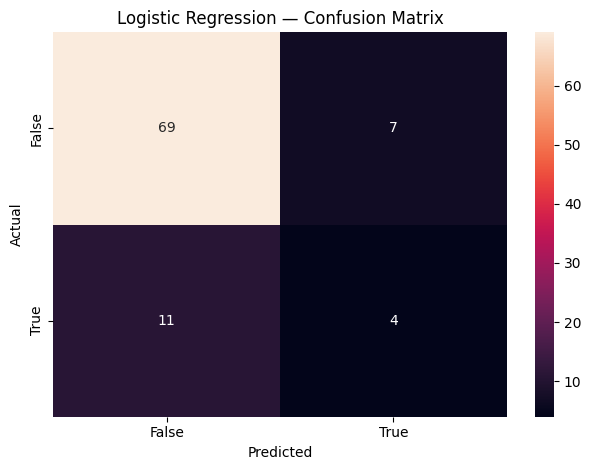

In [ ]:

cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['False', 'True'], yticklabels=['False', 'True'])
plt.title("Logistic Regression — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [ ]:

# --- Configuration ---
MODEL_NAME  = "dmis-lab/biobert-base-cased-v1.1"  # CHANGED
MAX_LEN     = 128    # Max tokens per claim (claims are short, 128 is enough)
BATCH_SIZE  = 16     # How many examples to process at once
EPOCHS      = 3      # Number of training passes (3 is standard for fine-tuning)
LR          = 2e-5   # Learning rate (standard for BERT fine-tuning)

# Check if GPU is available (Colab gives you a free T4 GPU — use it!)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla T4


In [ ]:

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class ClaimDataset(Dataset):
    """
    Converts a list of claim texts and labels into BERT-ready tensors.
    Think of it like a translator between your pandas DataFrame and PyTorch.
    """
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = list(texts)
        self.labels    = list(labels)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',    # Pad short texts to MAX_LEN
            truncation=True,         # Cut long texts at MAX_LEN
            return_tensors='pt'      # Return PyTorch tensors
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }


# Create datasets
train_dataset = ClaimDataset(X_train.values, y_train.values, tokenizer, MAX_LEN)
test_dataset  = ClaimDataset(X_test.values,  y_test.values,  tokenizer, MAX_LEN)

# Create data loaders (these feed batches to the model during training)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Training batches: {len(train_loader)}")
print(f"Test batches:     {len(test_loader)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/313 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Training batches: 23
Test batches:     6


In [ ]:
model_bert = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,          # Binary classification: 0 or 1
    ignore_mismatched_sizes=True
)
model_bert = model_bert.to(device)

# Optimizer — AdamW is standard for transformer fine-tuning
optimizer = AdamW(model_bert.parameters(), lr=LR, weight_decay=0.01)

# Learning rate scheduler — gradually reduces LR during training
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),  # Warm up for first 10% of steps
    num_training_steps=total_steps
)

print("BioBERT model loaded successfully!")
print(f"Total parameters: {sum(p.numel() for p in model_bert.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model_bert.parameters() if p.requires_grad):,}")

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.1
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were ne

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

BioBERT model loaded successfully!
Total parameters: 108,311,810
Trainable parameters: 108,311,810


In [ ]:
def train_epoch(model, loader, optimizer, scheduler, device):
    """One full pass over the training data."""
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch_idx, batch in enumerate(loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss    = outputs.loss
        logits  = outputs.logits

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Prevent exploding gradients
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

        # Print progress every 10 batches
        if (batch_idx + 1) % 10 == 0:
            print(f"  Batch {batch_idx+1}/{len(loader)} | Loss: {loss.item():.4f}", end='\r')

    avg_loss = total_loss / len(loader)
    accuracy = correct / total
    return avg_loss, accuracy


def evaluate(model, loader, device):
    """Evaluate model on test data — no gradient calculation needed."""
    model.eval()
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds   = torch.argmax(outputs.logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_labels, all_preds


# --- Run training ---
print("Starting BioBERT fine-tuning...\n")
train_losses = []

for epoch in range(EPOCHS):
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print("-" * 40)

    train_loss, train_acc = train_epoch(model_bert, train_loader, optimizer, scheduler, device)
    train_losses.append(train_loss)

    print(f"\n  Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.4f}")
    print()

print("Training complete!")

Starting BioBERT fine-tuning...

Epoch 1/3
----------------------------------------

  Train Loss: 0.4421 | Train Accuracy: 0.8352

Epoch 2/3
----------------------------------------

  Train Loss: 0.3596 | Train Accuracy: 0.8571

Epoch 3/3
----------------------------------------

  Train Loss: 0.2990 | Train Accuracy: 0.8984

Training complete!



--- BioBERT (Fine-tuned on Medical Claims) Results ---
              precision    recall  f1-score   support

   False (0)       0.86      0.96      0.91        76
    True (1)       0.50      0.20      0.29        15

    accuracy                           0.84        91
   macro avg       0.68      0.58      0.60        91
weighted avg       0.80      0.84      0.80        91

Accuracy: 0.8352


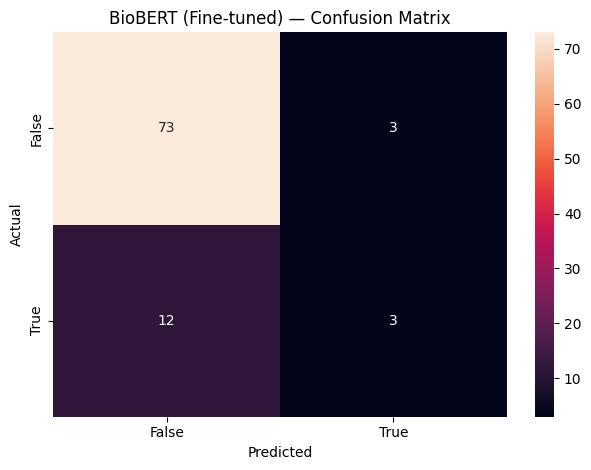

In [ ]:
y_true_bert, y_pred_bert = evaluate(model_bert, test_loader, device)

print("\n--- BioBERT (Fine-tuned on Medical Claims) Results ---")
print(classification_report(y_true_bert, y_pred_bert, target_names=['False (0)', 'True (1)']))
print("Accuracy:", round(accuracy_score(y_true_bert, y_pred_bert), 4))

# Confusion matrix
cm_bert = confusion_matrix(y_true_bert, y_pred_bert)
sns.heatmap(cm_bert, annot=True, fmt='d', xticklabels=['False', 'True'], yticklabels=['False', 'True'])
plt.title("BioBERT (Fine-tuned) — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

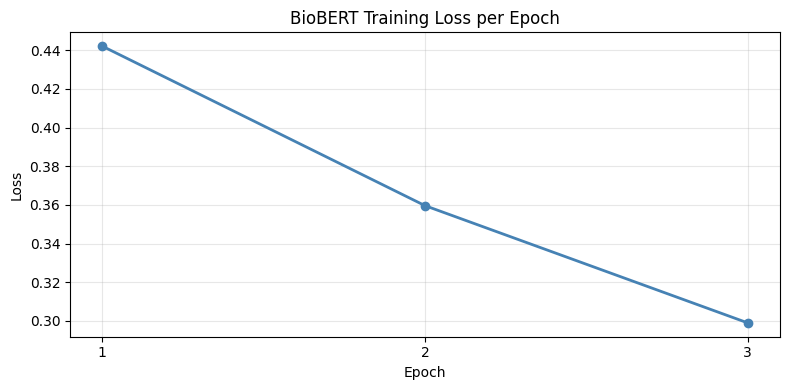

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS+1), train_losses, marker='o', color='steelblue', linewidth=2)
plt.title("BioBERT Training Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(range(1, EPOCHS+1))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

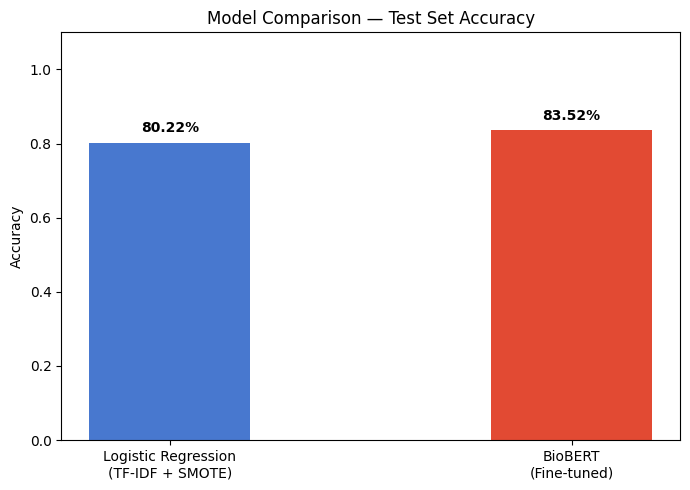

In [ ]:

lr_acc   = round(accuracy_score(y_test, y_pred_lr), 4)
bert_acc = round(accuracy_score(y_true_bert, y_pred_bert), 4)

models   = ['Logistic Regression\n(TF-IDF + SMOTE)', 'BioBERT\n(Fine-tuned)']
accuracy = [lr_acc, bert_acc]
colors   = ['#4878CF', '#E24A33']

plt.figure(figsize=(7, 5))
bars = plt.bar(models, accuracy, color=colors, width=0.4)
plt.ylim(0, 1.1)
plt.title("Model Comparison — Test Set Accuracy")
plt.ylabel("Accuracy")

# Add value labels on top of bars
for bar, acc in zip(bars, accuracy):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{acc:.2%}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:

def predict_claim(text, lr_model, bert_model, vectorizer, tokenizer, device, max_len=128):
    """
    Takes a health claim string and returns predictions from both models.
    """
    label_names = {0: "FALSE (misinformation)", 1: "TRUE (credible)"}

    # --- Logistic Regression prediction ---
    clean = clean_text(text)
    vec   = vectorizer.transform([clean])
    lr_pred  = lr_model.predict(vec)[0]
    lr_proba = lr_model.predict_proba(vec)[0]

    # --- BioBERT prediction ---
    bert_model.eval()
    encoding = tokenizer(
        text,
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    with torch.no_grad():
        outputs = bert_model(
            input_ids=encoding['input_ids'].to(device),
            attention_mask=encoding['attention_mask'].to(device)
        )
    probs      = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]
    bert_pred  = int(np.argmax(probs))

    print(f"\nClaim: \"{text}\"")
    print("-" * 60)
    print(f"Logistic Regression : {label_names[lr_pred]}  (confidence: {max(lr_proba):.1%})")
    print(f"BioBERT (fine-tuned): {label_names[bert_pred]}  (confidence: {max(probs):.1%})")


# Try it out
predict_claim(
    "Drinking hot water cures COVID-19",
    model_lr, model_bert, vectorizer, tokenizer, device
)

predict_claim(
    "Vaccines have been shown to reduce the risk of severe illness.",
    model_lr, model_bert, vectorizer, tokenizer, device
)

predict_claim(
    "Ivermectin is approved by WHO to treat COVID-19.",
    model_lr, model_bert, vectorizer, tokenizer, device
)


Claim: "Drinking hot water cures COVID-19"
------------------------------------------------------------
Logistic Regression : FALSE (misinformation)  (confidence: 68.2%)
BioBERT (fine-tuned): FALSE (misinformation)  (confidence: 82.4%)

Claim: "Vaccines have been shown to reduce the risk of severe illness."
------------------------------------------------------------
Logistic Regression : FALSE (misinformation)  (confidence: 62.2%)
BioBERT (fine-tuned): FALSE (misinformation)  (confidence: 73.5%)

Claim: "Ivermectin is approved by WHO to treat COVID-19."
------------------------------------------------------------
Logistic Regression : FALSE (misinformation)  (confidence: 78.5%)
BioBERT (fine-tuned): FALSE (misinformation)  (confidence: 78.3%)
